<a href="https://colab.research.google.com/github/hasan-ghavidel/deep-learning-basics/blob/main/simple_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import requests
from bs4 import BeautifulSoup
from PIL import Image
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor


# -------------------------
# Folders
# -------------------------

normal_path = "/content/data/normal"
tb_path = "/content/data/tb"

os.makedirs(normal_path, exist_ok=True)
os.makedirs(tb_path, exist_ok=True)


# -------------------------
# Delete old images
# -------------------------

for folder in [normal_path, tb_path]:

    for filename in os.listdir(folder):

        file_path = os.path.join(folder, filename)

        if os.path.isfile(file_path):
            os.remove(file_path)


# -------------------------
# Dataset URL
# -------------------------

url = "https://data.lhncbc.nlm.nih.gov/public/Tuberculosis-Chest-X-ray-Datasets/Shenzhen-Hospital-CXR-Set/CXR_png/index.html"

base_url = url.rsplit("/", 1)[0] + "/"


# -------------------------
# Get image links
# -------------------------

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

links = []

for link in soup.find_all("a"):

    href = link.get("href")

    if href and href.endswith(".png"):
        links.append(href)


print("Total images found:", len(links))


# -------------------------
# Download one image
# -------------------------

def download_image(href):

    filename = os.path.basename(href)

    image_url = base_url + href

    try:

        image_data = requests.get(
            image_url,
            timeout=30
        ).content

        image = Image.open(
            BytesIO(image_data)
        ).convert("L")

        image = image.resize((128, 128))

        # Normal
        if "_0.png" in filename:

            save_path = os.path.join(
                normal_path,
                filename
            )

            image.save(save_path)

            return "normal"

        # TB
        elif "_1.png" in filename:

            save_path = os.path.join(
                tb_path,
                filename
            )

            image.save(save_path)

            return "tb"

    except Exception as e:

        print("Error:", filename, e)

        return "error"


# -------------------------
# Download in parallel
# -------------------------

normal_count = 0
tb_count = 0

with ThreadPoolExecutor(max_workers=10) as executor:

    results = executor.map(download_image, links)

    for i, result in enumerate(results, 1):

        if result == "normal":
            normal_count += 1

        elif result == "tb":
            tb_count += 1

        if i % 20 == 0:
            print(
                "Downloaded:",
                i,
                "/",
                len(links)
            )


# -------------------------
# Final result
# -------------------------

print()
print("Normal images:", normal_count)
print("TB images:", tb_count)
print("Total:", normal_count + tb_count)

Total images found: 662
Downloaded: 20 / 662
Downloaded: 40 / 662
Downloaded: 60 / 662
Downloaded: 80 / 662
Downloaded: 100 / 662
Downloaded: 120 / 662
Downloaded: 140 / 662
Downloaded: 160 / 662
Downloaded: 180 / 662
Downloaded: 200 / 662
Downloaded: 220 / 662
Downloaded: 240 / 662
Downloaded: 260 / 662
Downloaded: 280 / 662
Downloaded: 300 / 662
Downloaded: 320 / 662
Downloaded: 340 / 662
Downloaded: 360 / 662
Downloaded: 380 / 662
Downloaded: 400 / 662
Downloaded: 420 / 662
Downloaded: 440 / 662
Downloaded: 460 / 662
Downloaded: 480 / 662
Downloaded: 500 / 662
Downloaded: 520 / 662
Downloaded: 540 / 662
Downloaded: 560 / 662
Downloaded: 580 / 662
Downloaded: 600 / 662
Downloaded: 620 / 662
Downloaded: 640 / 662
Downloaded: 660 / 662

Normal images: 326
TB images: 336
Total: 662


Image size: (128, 128)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

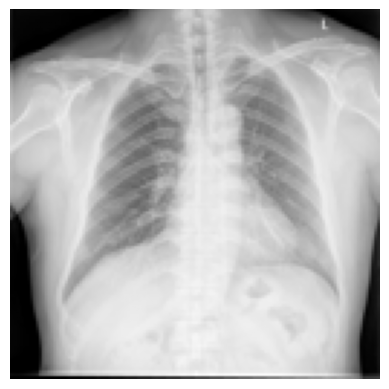

In [ ]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

image_path = "/content/data/normal/CHNCXR_0001_0.png"

image = Image.open(image_path)

print("Image size:", image.size)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

image_array = np.array(image)

x = torch.tensor(image_array, dtype=torch.float32)

x = x.flatten()

print(x.shape)

torch.Size([16384])


In [20]:
import os
import torch
import torch.nn as nn
from PIL import Image


# ============================================
# 1. Load images
# ============================================

X = []
y = []

# --------------------------------------------
# Normal images
# --------------------------------------------

normal_path = "/content/data/normal"

for filename in os.listdir(normal_path):

    image = Image.open(
        os.path.join(normal_path, filename)
    ).convert("L")

    # Convert pixels to tensor
    x = torch.tensor(
        list(image.getdata()),
        dtype=torch.float32
    )

    # Normalize pixels: 0-255 -> 0-1
    x = x / 255.0

    # 128 x 128 -> 16384
    x = x.flatten()

    X.append(x)

    # Normal = 0
    y.append(0)


# --------------------------------------------
# TB images
# --------------------------------------------

tb_path = "/content/data/tb"

for filename in os.listdir(tb_path):

    image = Image.open(
        os.path.join(tb_path, filename)
    ).convert("L")

    # Convert pixels to tensor
    x = torch.tensor(
        list(image.getdata()),
        dtype=torch.float32
    )

    # Normalize pixels: 0-255 -> 0-1
    x = x / 255.0

    # 128 x 128 -> 16384
    x = x.flatten()

    X.append(x)

    # TB = 1
    y.append(1)


# ============================================
# 2. Convert lists to tensors
# ============================================

X = torch.stack(X)
y = torch.tensor(y)


print("Total images:", len(X))
print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================
# 3. Shuffle the dataset
# ============================================

indices = torch.randperm(len(X))

X = X[indices]
y = y[indices]


# ============================================
# 4. Train / Test split
# ============================================

train_X = X[:500]
train_y = y[:500]

test_X = X[500:]
test_y = y[500:]


print("Train:", len(train_X))
print("Test:", len(test_X))


# ============================================
# 5. Define MLP
# ============================================

class Mlp(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(
            128 * 128,
            64
        )

        self.act = nn.ReLU()

        self.fc2 = nn.Linear(
            64,
            2
        )


    def forward(self, x):

        x = self.fc1(x)

        x = self.act(x)

        x = self.fc2(x)

        return x


# ============================================
# 6. Create model
# ============================================

model = Mlp()


# ============================================
# 7. Loss function
# ============================================

loss_function = nn.CrossEntropyLoss()


# ============================================
# 8. Optimizer
# ============================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)


# ============================================
# 9. Training
# ============================================

best_loss = float("inf")

for epoch in range(1000):

    # Model sees ONLY training images
    output = model(train_X)

    # Calculate loss
    loss = loss_function(
        output,
        train_y
    )

    # Reset old gradients
    optimizer.zero_grad()

    # Calculate gradients
    loss.backward()

    # Update weights
    optimizer.step()


    # ========================================
    # Save the best model
    # ========================================

    current_loss = loss.item()

    if current_loss < best_loss:

        best_loss = current_loss

        torch.save(
            model.state_dict(),
            "/content/data/best_model.pth"
        )

        print(
            "New best model | "
            "Epoch:", epoch,
            "| Loss:", best_loss
        )


    # Print loss every 5 epochs
    if epoch % 5 == 0:

        print(
            "Epoch:",
            epoch,
            "Loss:",
            current_loss
        )


# ============================================
# 10. Training finished
# ============================================

print()
print("Training finished.")
print("Best training loss:", best_loss)
print("Model saved at:")
print("/content/data/best_model.pth")

Total images: 662
X shape: torch.Size([662, 16384])
y shape: torch.Size([662])
Train: 500
Test: 162
New best model | Epoch: 0 | Loss: 0.6979724764823914
Epoch: 0 Loss: 0.6979724764823914
New best model | Epoch: 2 | Loss: 0.6820229887962341
Epoch: 5 Loss: 0.7208595871925354
New best model | Epoch: 8 | Loss: 0.6754393577575684
Epoch: 10 Loss: 0.6866927146911621
New best model | Epoch: 13 | Loss: 0.6732300519943237
New best model | Epoch: 14 | Loss: 0.6652303338050842
New best model | Epoch: 15 | Loss: 0.6595498919487
Epoch: 15 Loss: 0.6595498919487
New best model | Epoch: 16 | Loss: 0.6566877961158752
New best model | Epoch: 17 | Loss: 0.6541138291358948
New best model | Epoch: 18 | Loss: 0.6504185795783997
New best model | Epoch: 19 | Loss: 0.6464232206344604
New best model | Epoch: 20 | Loss: 0.6416628956794739
Epoch: 20 Loss: 0.6416628956794739
New best model | Epoch: 21 | Loss: 0.6372849345207214
New best model | Epoch: 22 | Loss: 0.6341028809547424
New best model | Epoch: 23 | Loss:

Test image index: 35
True label: 0
Predicted label: 0
True class: Normal
Predicted class: Normal


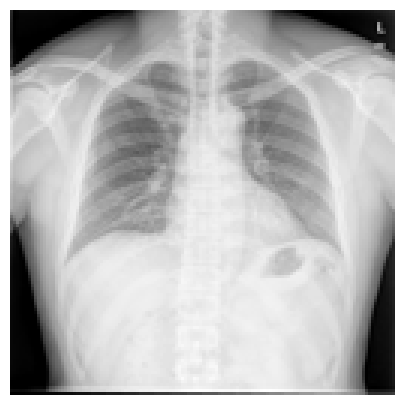

In [25]:
# ============================================
# Evaluation - One Test Image
# ============================================

import random
import matplotlib.pyplot as plt


# 1. Create the model
model = Mlp()


# 2. Load the best saved model
model.load_state_dict(
    torch.load(
        "/content/data/best_model.pth",
        weights_only=True
    )
)


# 3. Put model in evaluation mode
model.eval()


# 4. Select one random image from Test set
index = random.randint(
    0,
    len(test_X) - 1
)

x = test_X[index]
true_label = test_y[index]


# 5. Make prediction
with torch.no_grad():

    output = model(
        x.unsqueeze(0)
    )

    predicted_label = torch.argmax(
        output,
        dim=1
    )


# 6. Print results

print("Test image index:", index)

print(
    "True label:",
    true_label.item()
)

print(
    "Predicted label:",
    predicted_label.item()
)


# 7. Convert labels to names

if true_label.item() == 0:
    print("True class: Normal")
else:
    print("True class: TB")


if predicted_label.item() == 0:
    print("Predicted class: Normal")
else:
    print("Predicted class: TB")


# 8. Show the image

plt.figure(figsize=(5, 5))

plt.imshow(
    x.reshape(128, 128),
    cmap="gray"
)

plt.axis("off")

plt.show()